## 1. Data Pre-Processing
### Cleaning up the data fields

In [1]:
%pip install -r ../requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import wordcloud
import ipywidgets as widgets
from IPython.display import display, Markdown

In [3]:
challenges = '../output/sentiments/challenges.csv'
expectations = '../output/sentiments/expectations.csv'

In [4]:
df_painpoints = pd.read_csv(challenges, engine='python', on_bad_lines='skip')
df_expectations = pd.read_csv(expectations, engine='python', on_bad_lines='skip')

# Normalize column names to avoid issues from hidden spaces in headers.
df_painpoints.columns = df_painpoints.columns.str.strip()
df_expectations.columns = df_expectations.columns.str.strip()

In [5]:
df_painpoints.shape, df_expectations.shape

((345, 7), (267, 7))

In [6]:
#drop the pain_points rows containing "Other", "IPS related"
df_painpoints = df_painpoints[~df_painpoints['Pain Point'].str.contains('Other|IPS related', case=False, na=False)]
df_expectations = df_expectations[~df_expectations['Expectation'].str.contains('Other|IPS related', case=False, na=False)]

In [7]:
# (optional )create new column 'pain_point_desc' and split on first ':' if present
# df_painpoints['pain_point_desc'] = ''
# mask = df_painpoints['Pain Point'].fillna('').str.contains(':')
# df_painpoints.loc[mask, 'pain_point_desc'] = df_painpoints.loc[mask, 'Pain Point'].str.split(':', n=1).str[1].str.strip()
# df_painpoints.loc[mask, 'Pain Point'] = df_painpoints.loc[mask, 'Pain Point'].str.split(':', n=1).str[0].str.strip()

# #create new column 'expectation_desc' and split on first ':' if present
# df_expectations['expectation_desc'] = ''
# mask = df_expectations['Expectation'].fillna('').str.contains(':')
# df_expectations.loc[mask, 'expectation_desc'] = df_expectations.loc[mask, 'Expectation'].str.split(':', n=1).str[1].str.strip()
# df_expectations.loc[mask, 'Expectation'] = df_expectations.loc[mask, 'Expectation'].str.split(':', n=1).str[0].str.strip()

In [8]:
# create a new column to represent the string length of the pain point and expectation
df_painpoints['word_count'] = df_painpoints['Pain Point'].str.split().str.len()
df_expectations['word_count'] = df_expectations['Expectation'].str.split().str.len()

In [9]:
df_painpoints.sample(5, random_state=42)

,Focus Group,Pain Point,processed_content,label,VADER,Business Score,processed_pain_points,word_count
194,DOCE Supervisors,No Automatic Monitoring: No system-generated a...,automatic monitoring alert inactive stalled case,positive,-0.6369,0,automatic monitoring alert inactive stalled case,11
157,Assessment Assessment Supervisors,Seasonal Review Process: Permit monitoring and...,seasonal review process permit monitoring fiel...,neutral,0.0000,0,seasonal review process permit monitoring fiel...,18
225,DOCE Zoning,Missing Supporting Documentation: Older zoning...,missing supporting documentation older zoning ...,positive,0.5423,-6,missing supporting documentation older zoning ...,16
208,DOCE Supervisors,No Batch Processing: Large-scale updates and c...,batch processing update cleanup activity diffi...,negative,-0.5719,-3,batch processing update cleanup activity diffi...,12
319,DOCE Housing Inspectors,No Global Case View: Difficult to review all a...,global case view difficult review active close...,positive,-0.2500,-3,global case view difficult review active close...,16


In [10]:
df_expectations.sample(5, random_state=42)

,Focus Group,Expectation,processed_content,label,VADER,Business Score,processed_expectations,word_count
84,DOCE CommercialPermitElectrical Inspectors,Integrated Permit Workflow: Connect permitting...,integrated permit workflow connect permitting ...,neutral,0.0000,5,integrated permit workflow connect permitting ...,11
46,DOCE Building Inspectors,More Reliable Data Storage: Prevent loss of en...,reliable data storage prevent loss entered inf...,negative,-0.2960,0,reliable data storage prevent loss entered inf...,9
183,DOCE Office Manager,Improved reliability and stability.,improved reliability stability,positive,0.4767,6,improved reliability stability,4
236,DOCE Housing Inspectors,Cases Needing Review Dashboard: Identify cases...,case needing review dashboard identify case re...,neutral,0.0000,2,case needing review dashboard identify case re...,8
177,DOCE Office Manager,Easier access to historical records.,easier access historical record,positive,0.4215,3,easier access historical record,5


In [11]:
# show the rows where word_count is less than 5 for pain points and expectations
df_painpoints[df_painpoints['word_count'] <= 4]

,Focus Group,Pain Point,processed_content,label,VADER,Business Score,processed_pain_points,word_count
13,CPO Central Permit Office,Application & Review Challenges,application review challenge,positive,0.0772,0,application review challenge,4
20,CPO CPO Co-Ordinator,System Performance & Usability,system performance usability,neutral,0.0000,0,system performance usability,4
36,CPO CPO Co-Ordinator,Scheduling & Communication Challenges,scheduling communication challenge,positive,0.0772,0,scheduling communication challenge,4
47,DOCE Building Inspectors,Ownership & Property Information,ownership property information,neutral,0.0000,0,ownership property information,4
70,DOCE CommercialPermitElectrical Inspectors,System Performance & Usability,system performance usability,neutral,0.0000,0,system performance usability,4
80,DOCE CommercialPermitElectrical Inspectors,Data & Information Challenges,data information challenge,positive,0.0772,0,data information challenge,4
158,DOCE Admin Aide,System Performance & Usability,system performance usability,neutral,0.0000,0,system performance usability,4
172,DOCE Admin Aide,Save functions are inconsistent.,save function inconsistent,positive,0.4939,0,save function inconsistent,4
183,DOCE Admin Aide,Training & Knowledge Challenges,training knowledge challenge,positive,0.0772,0,training knowledge challenge,4
198,DOCE Supervisors,Data & Information Issues,data information issue,neutral,0.0000,-2,data information issue,4


In [12]:
#drop the rows containing less than or equal to 4 words in pain_points and expectations
df_painpoints = df_painpoints[df_painpoints['word_count'] >= 4].drop(columns=['word_count'])
df_expectations = df_expectations[df_expectations['word_count'] >= 4].drop(columns=['word_count'])

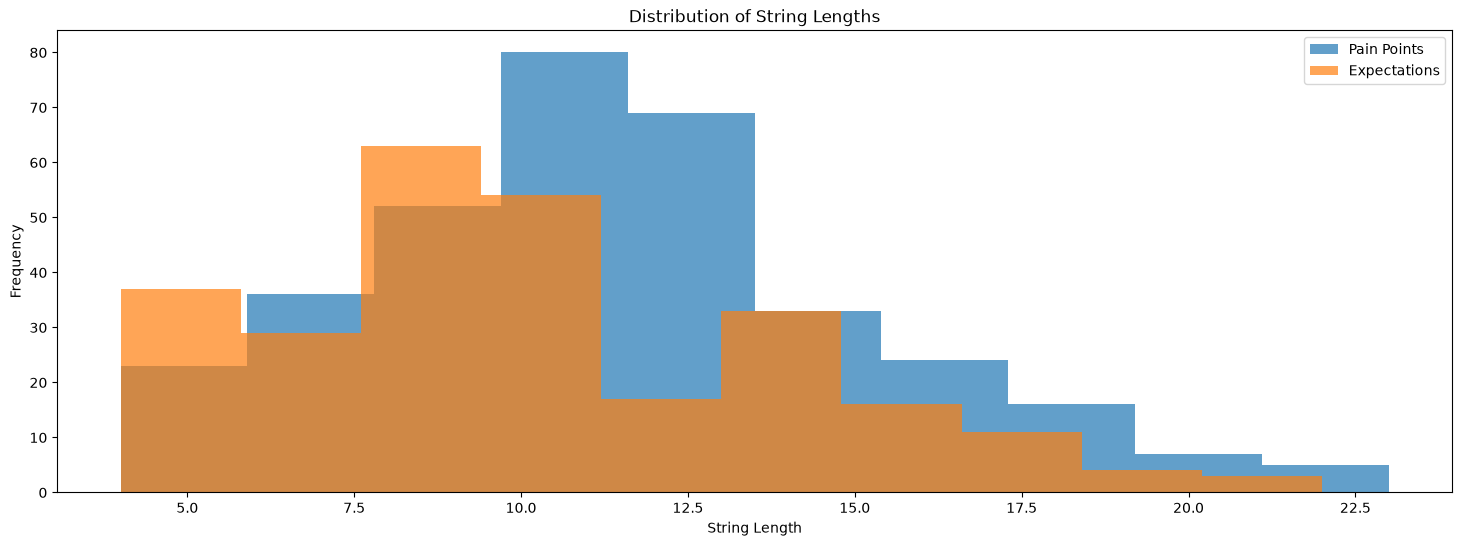

In [13]:
#plot the distribution of string lengths for pain points and expectations
plt.figure(figsize=(18, 6))
hist_pain = plt.hist(df_painpoints['Pain Point'].str.split().str.len(), alpha=0.7, label='Pain Points')
hist_expect = plt.hist(df_expectations['Expectation'].str.split().str.len(), alpha=0.7, label='Expectations')
plt.xlabel('String Length')
plt.ylabel('Frequency')
plt.title('Distribution of String Lengths')
plt.legend()

In [14]:
#drop the rows containing less than or equal to 4 words in pain_points and expectations
df_painpoints = df_painpoints[df_painpoints['Pain Point'].str.split().str.len() > 4]
df_expectations = df_expectations[df_expectations['Expectation'].str.split().str.len() > 4]

### Finder function

In [15]:
def get_pain_points(keyword, optional_keywords=None, sentiment=None):
    """
    Get pain points based on keywords.

    Parameters:
    keyword (str or list): The main keyword or keywords that must be present in the pain points.
    optional_keywords (list, optional): List of additional keywords that may also appear in the same record.
    sentiment (str, optional): The sentiment to filter by.

    Returns:
    DataFrame: Filtered DataFrame containing pain points that match the keywords.
    """
    required_keywords = keyword if isinstance(keyword, list) else [keyword]
    required_mask = df_painpoints['processed_content'].str.contains('|'.join(required_keywords), case=False, na=False)

    filtered_pain_points = df_painpoints[required_mask]

    if optional_keywords:
        optional_mask = filtered_pain_points['processed_content'].str.contains('|'.join(optional_keywords), case=False, na=False)
        filtered_pain_points = filtered_pain_points[optional_mask]

    if sentiment is not None:
        filtered_pain_points = filtered_pain_points[filtered_pain_points['label'] == sentiment]
    return filtered_pain_points

In [16]:
def get_expectations(keyword, optional_keywords=None, sentiment=None):
    """
    Get expectations based on keywords.

    Parameters:
    keyword (str or list): The main keyword or keywords to search for in the expectations.
    optional_keywords (list, optional): List of additional keywords to search for.
    sentiment (str, optional): The sentiment to filter by.

    Returns:
    DataFrame: Filtered DataFrame containing expectations that match the keywords.
    """
    keywords = keyword if isinstance(keyword, list) else [keyword]
    if optional_keywords:
        keywords.extend(optional_keywords)

    filtered_expectations = df_expectations[df_expectations['processed_content'].str.contains('|'.join(keywords), case=False, na=False)]
    if sentiment is not None:
        filtered_expectations = filtered_expectations[filtered_expectations['label'] == sentiment]
    return filtered_expectations

In [17]:
df_painpoints.sample(5)

,Focus Group,Pain Point,processed_content,label,VADER,Business Score,processed_pain_points
157,Assessment Assessment Supervisors,Seasonal Review Process: Permit monitoring and...,seasonal review process permit monitoring fiel...,neutral,0.0000,0,seasonal review process permit monitoring fiel...
139,NBD NBD Internal,Enhanced Search Capabilities: Improve searchin...,enhanced search capability improve searching a...,positive,0.4404,-1,enhanced search capability improve searching a...
283,DOCE Fire Prevention Bureau,"Large Volume of Documentation: Managing plans,...",large volume documentation managing plan inspe...,positive,0.0000,0,large volume documentation managing plan inspe...
53,DOCE Building Inspectors,Too Much Information in Different Areas: Impor...,much information different area important info...,positive,0.2023,0,much information different area important info...
27,CPO CPO Co-Ordinator,Expiration Tracking Limitations: Renewal track...,expiration tracking limitation renewal trackin...,negative,0.0000,0,expiration tracking limitation renewal trackin...


In [18]:
IPS_crashes = get_pain_points(['IPS'], optional_keywords=['crash', 'crashing','freezing', 'lag', 'slow', 'unresponsive', 'stuck', 'hang', 'freeze', 'navigat', 'interface', 'in-field', 'infield', 'in field', 'dashboard'], sentiment='negative') 
print(f"Total number of pain points related to IPS crashing issues: {len(IPS_crashes)}")

Total number of pain points related to IPS crashing issues: 0


In [19]:
#store this as csv files for further analysis
df_painpoints.to_csv('../output/cleaned_challenges.csv', index=False)
df_expectations.to_csv('../output/cleaned_expectations.csv', index=False)

In [20]:
#function to calculate amount of times a keyword appears in a pain point 
def count_keyword_occurrences(keyword, case_sensitive=False):
    return df_painpoints.loc[
        df_painpoints['Pain Point'].str.contains(keyword, case=case_sensitive, na=False)
    ].shape[0]

In [21]:
count_keyword_occurrences('crash|Crash|freez|Freez|slow|Slow|lag|Lag|hang|Hang|unresponsive|Unresponsive|shutdown|Shutdown|freeze|Freeze|lock|Lock|stuck|Stuck|')

329

In [22]:
# display the records where the pain point contains the keyword 'Crashes'
df_painpoints[df_painpoints['Pain Point'].str.contains('crash|Crash|freez|Freez|slow|Slow|lag|Lag|hang|Hang|unresponsive|Unresponsive|shutdown|Shutdown|freeze|Freeze|lock|Lock|stuck|Stuck|', na=False)]

,Focus Group,Pain Point,processed_content,label,VADER,Business Score,processed_pain_points
0,CPO Central Permit Office,Split Permit & Code Systems: Permit and Code E...,split permit code system permit code enforceme...,neutral,0.0000,0,split permit code system permit code enforceme...
1,CPO Central Permit Office,Scattered Information: Property and permit inf...,scattered information property permit informat...,neutral,0.0000,-3,scattered information property permit informat...
2,CPO Central Permit Office,Research Complexity: Users must search multipl...,research complexity user must search multiple ...,neutral,0.0000,-4,research complexity user must search multiple ...
3,CPO Central Permit Office,Difficult Information Retrieval: Finding relev...,difficult information retrieval finding releva...,neutral,0.0000,-5,difficult information retrieval finding releva...
4,CPO Central Permit Office,Limited IPS-Camino Integration: Information do...,limited integration information flow seamlessl...,negative,-0.2263,-2,limited integration information flow seamlessl...
...,...,...,...,...,...,...,...
340,DOCE Housing Inspectors,Manual Tracking: Inspectors maintain spreadshe...,manual tracking inspector maintain spreadsheet...,neutral,0.0000,-3,manual tracking inspector maintain spreadsheet...
341,DOCE Housing Inspectors,Lead Map Verification: Frequent manual checkin...,lead map verification frequent manual checking...,neutral,0.0000,-3,lead map verification frequent manual checking...
342,DOCE Housing Inspectors,Violation Entry Delays: Simultaneous data entr...,violation entry delay simultaneous data entry ...,negative,-0.7506,-4,violation entry delay simultaneous data entry ...
343,DOCE Housing Inspectors,Large Dropdown Lists: Long dropdown menus make...,large dropdown list long dropdown menu make da...,neutral,0.0000,0,large dropdown list long dropdown menu make da...


In [23]:
count_keyword_occurrences('many system|multiple system', case_sensitive=False)

16

In [24]:
df_painpoints[df_painpoints['Pain Point'].str.contains('many system|multiple system', na=False)]

,Focus Group,Pain Point,processed_content,label,VADER,Business Score,processed_pain_points
2,CPO Central Permit Office,Research Complexity: Users must search multipl...,research complexity user must search multiple ...,neutral,0.0000,-4,research complexity user must search multiple ...
3,CPO Central Permit Office,Difficult Information Retrieval: Finding relev...,difficult information retrieval finding releva...,neutral,0.0000,-5,difficult information retrieval finding releva...
34,CPO CPO Co-Ordinator,"Split Workflows: Licensing, permitting, and re...",split workflow licensing permitting registry p...,neutral,0.0000,-2,split workflow licensing permitting registry p...
61,DOCE Building Inspectors,No Single Source of Truth: Information needed ...,single source truth information needed inspect...,positive,0.0258,-2,single source truth information needed inspect...
82,DOCE CommercialPermitElectrical Inspectors,No Unified Permit Record: Information is sprea...,unified permit record information spread acros...,positive,0.1027,-2,unified permit record information spread acros...
106,CPC CPC,Duplicate Data Entry: Staff repeatedly enter t...,duplicate data entry staff repeatedly enter in...,neutral,0.0000,-4,duplicate data entry staff repeatedly enter in...
108,CPC CPC,Fragmented Information Sources: Staff rely on ...,fragmented information source staff rely multi...,neutral,0.0000,-7,fragmented information source staff rely multi...
133,NBD NBD Internal,Fragmented Information Sources: Staff must sea...,fragmented information source staff must searc...,neutral,0.0000,-7,fragmented information source staff must searc...
163,DOCE Admin Aide,Inspection appointments must be entered into m...,inspection appointment must entered multiple s...,neutral,0.0000,-2,inspection appointment must entered multiple s...
224,DOCE Zoning,Scattered Project Information: Project documen...,scattered project information project document...,positive,-0.3612,-8,scattered project information project document...
